In [1]:
%run "coli starting run.ipynb"

In [2]:


score_borad = data_create(0,0,0,0)
for i in range(50):
    true_score = i*10+101
    score_borad = pd.concat([score_borad,data_create(50,my_floor(true_score,-2),true_score,0)]).reset_index(drop=True)
    score_borad = pd.concat([score_borad,data_create(50,my_floor(true_score,-2),true_score,1)]).reset_index(drop=True)



score_borad['int_score'] = score_borad['score']
score_borad['play_time'] = score_borad.apply(lambda x: 0 if x['type']==1 else x['play_time'],axis=1)
#score_borad['score'] = score_borad['score']-100
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score
0,100.0,101,0,0,0,0,0,0,14.0,100.0
1,100.0,101,0,0,0,0,0,0,0.0,100.0
2,100.0,101,0,0,0,0,0,0,17.0,100.0
3,100.0,101,0,0,0,0,0,0,1.0,100.0
4,100.0,101,0,0,0,0,0,0,4.0,100.0
...,...,...,...,...,...,...,...,...,...,...
4995,500.0,591,0,0,0,0,0,1,0.0,500.0
4996,500.0,591,0,0,0,0,0,1,0.0,500.0
4997,500.0,591,0,0,0,0,0,1,0.0,500.0
4998,500.0,591,0,0,0,0,0,1,0.0,500.0


In [3]:
np.random.seed(5)
for i in range(20):
    score_borad = score_borad.sample(frac=1)
    print(i,end="\r", flush=True)
    for id_1 in score_borad.index:
        if score_borad.loc[id_1,'type'] == 2:
            if (i<5):
                score_borad.loc[id_1,'skiped time'] = score_borad.loc[id_1,'skiped time']+1
                continue
        if score_borad.loc[id_1,'att count'] >=score_borad.loc[id_1,'play_time']:
            continue
        pick_list = abs(score_borad['score'] - score_borad.loc[id_1,'score']).drop(id_1).sample(frac=1).sort_values().head(2)
        pick_list = score_borad.loc[pick_list.index]
        id_2 = pick_list[pick_list['true score']==pick_list['true score'].min()].index[0]#np.random.choice(pick_list.index)
        s1,s2 = coli_fight2(score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'],score_borad.loc[id_1,'true score'],score_borad.loc[id_2,'true score'])
        if s1 > score_borad.loc[id_1,'score']:
            score_borad.loc[id_1,'att win'] = score_borad.loc[id_1,'att win']+1
        else:
            score_borad.loc[id_2,'def win'] = score_borad.loc[id_2,'def win']+1
        score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'] = s1,s2
        score_borad.loc[id_1,'att count'],score_borad.loc[id_2,'def count'] = score_borad.loc[id_1,'att count']+1,score_borad.loc[id_2,'def count']+1
score_borad['scorediff'] = score_borad['score'] - score_borad['int_score']
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score,scorediff
1070,200.0,201,0,0,6,0,2,1,0.0,200.0,0.0
4490,540.0,541,0,0,5,0,3,1,0.0,500.0,40.0
1850,200.0,281,0,0,0,0,0,1,0.0,200.0,0.0
3070,390.0,401,0,0,7,0,2,1,0.0,400.0,-10.0
4130,580.0,511,0,8,14,7,3,0,8.0,500.0,80.0
...,...,...,...,...,...,...,...,...,...,...,...
2214,310.0,321,0,3,8,1,3,0,3.0,300.0,10.0
2088,350.0,301,0,0,7,0,4,1,0.0,300.0,50.0
1789,190.0,271,0,0,1,0,0,1,0.0,200.0,-10.0
3916,530.0,491,0,18,2,10,1,0,18.0,400.0,130.0


<AxesSubplot:xlabel='score', ylabel='true score'>

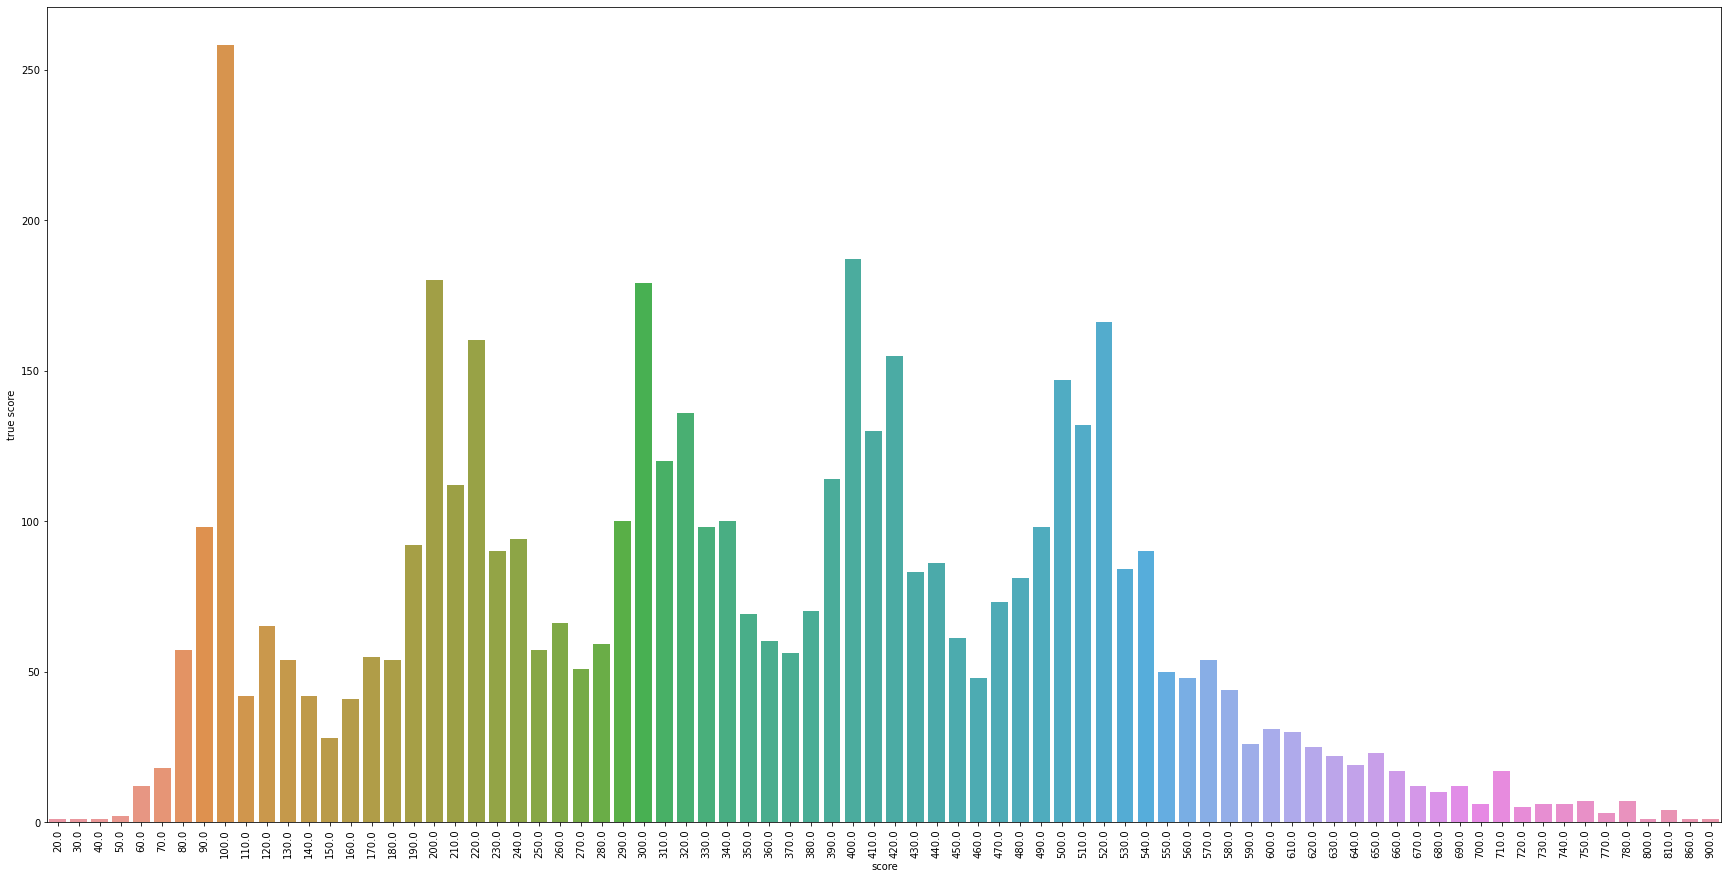

In [4]:
review_df = score_borad.groupby('score')['true score'].count()
fig, ax = plt.subplots(1,figsize=(30, 15),sharey=True)
ax.tick_params(axis='x',labelrotation=90)
sns.barplot(review_df.index,review_df)
#review_df

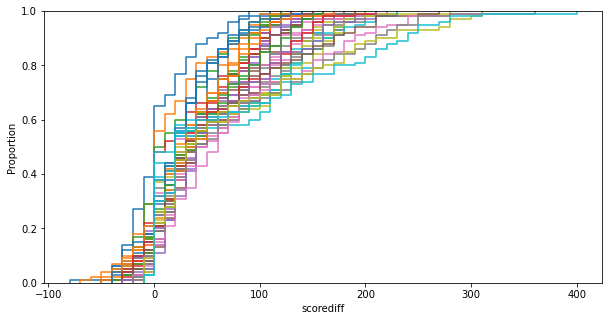

In [5]:


#review_df =score_borad.groupby('scorediff')['true score'].count()/len(score_borad)
kk = score_borad['true score'].unique()
kk.sort()
fig, ax = plt.subplots(1,figsize=(10, 5),sharey=True)
for t_score in kk:
    
    #ax.set_title(str(t_score))
    sns.ecdfplot(data = score_borad[score_borad['true score']==t_score],x="scorediff")
    #fig.show()

In [6]:
score_borad.pivot_table(index ='true score',columns='type' )#.loc[300:399]

att count      att win      def count       def win        \
type               0    1       0    1         0     1       0     1   
true score                                                             
101            10.30  0.0    4.80  0.0      7.32  4.72    1.76  1.26   
111             8.36  0.0    4.08  0.0      7.88  3.54    2.42  1.08   
121             9.10  0.0    4.92  0.0      7.00  4.02    1.78  1.40   
131            10.22  0.0    5.36  0.0      7.02  2.88    2.58  0.92   
141             9.96  0.0    5.40  0.0      6.38  3.16    2.34  1.40   
151            11.02  0.0    6.04  0.0      5.76  2.10    2.34  0.90   
161             9.98  0.0    6.04  0.0      5.42  1.84    1.98  1.04   
171             9.38  0.0    5.70  0.0      5.70  1.64    2.84  0.78   
181             8.84  0.0    5.82  0.0      4.76  0.70    2.32  0.56   
191             8.12  0.0    5.60  0.0      3.24  0.20    1.56  0.10   
201            10.18  0.0    5.06  0.0      7.82  5.34    2.32  2.04   
211             9.22  0.0    4.78  0.0      8.42  4.60    2.82  1.86   
221             9.92  0.0    5.56  0.0      8.30  4.22    2.80  1.78   
231            10.10  0.0    5.62  0.0      7.06  4.14    2.26  1.86   
241             9.18  0.0    5.42  0.0      7.00  3.68    2.42  1.84   
251             9.44  0.0    5.42  0.0      6.62  3.16    2.80  1.72   
261            10.40  0.0    6.40  0.0      5.92  1.96    2.38  1.14   
271             9.38  0.0    6.24  0.0      5.12  1.54    2.02  0.98   
281            10.30  0.0    6.56  0.0      4.52  0.96    2.00  0.58   
291             8.52  0.0    5.90  0.0      3.94  0.36    1.86  0.30   
301             9.50  0.0    4.90  0.0      8.48  6.34    2.54  2.70   
311            10.44  0.0    5.50  0.0      7.94  4.82    2.62  1.98   
321             9.00  0.0    4.96  0.0      7.24  4.60    2.44  1.92   
331             8.74  0.0    4.76  0.0      7.62  3.86    2.94  1.90   
341             8.02  0.0    4.64  0.0      6.06  4.26    2.32  2.44   
351            10.02  0.0    5.80  0.0      6.32  2.34    2.34  1.38   
361             9.46  0.0    5.80  0.0      5.78  2.28    2.40  1.36   
371             8.16  0.0    5.42  0.0      4.54  1.68    1.80  1.06   
381            10.12  0.0    6.68  0.0      5.02  1.10    2.18  0.70   
391            10.50  0.0    6.86  0.0      4.72  0.44    2.26  0.32   
401             9.66  0.0    4.72  0.0      7.84  5.74    2.32  2.24   
411             9.54  0.0    4.98  0.0      8.96  5.08    2.94  2.00   
421            10.76  0.0    5.64  0.0      7.40  5.42    2.54  2.42   
431             9.82  0.0    5.12  0.0      7.34  4.34    2.76  2.02   
441             8.32  0.0    4.92  0.0      6.38  3.26    2.48  1.64   
451             9.54  0.0    5.20  0.0      5.44  3.30    2.42  1.96   
461             9.70  0.0    5.96  0.0      5.76  2.04    2.56  1.46   
471             9.54  0.0    6.20  0.0      6.30  1.98    2.82  1.34   
481            10.32  0.0    6.96  0.0      5.50  0.80    2.28  0.68   
491             9.98  0.0    6.62  0.0      3.96  0.32    1.84  0.22   
501             9.42  0.0    4.96  0.0      8.04  5.66    2.24  2.26   
511            10.14  0.0    5.46  0.0      9.10  5.30    3.12  2.30   
521            10.16  0.0    5.84  0.0      8.92  4.74    3.20  2.00   
531            10.40  0.0    6.22  0.0      8.76  4.92    3.02  2.24   
541             9.24  0.0    6.04  0.0      9.82  3.82    3.64  2.06   
551             9.86  0.0    6.58  0.0      8.22  2.90    3.04  1.46   
561             9.94  0.0    7.10  0.0      7.58  3.52    2.92  2.16   
571             9.20  0.0    6.98  0.0      6.70  1.54    2.86  1.00   
581             8.58  0.0    6.74  0.0      4.22  1.24    2.10  0.92   
591             9.84  0.0    7.96  0.0      1.72  0.56    0.90  0.48   

           int_score        play_time       score        scorediff        \
type               0      1         0    1      0      1         0     1   
true score                                

In [7]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[300:399]

att count      att win      def count       def win        \
type               0    1       0    1         0     1       0     1   
true score                                                             
301             9.50  0.0    4.90  0.0      8.48  6.34    2.54  2.70   
311            10.44  0.0    5.50  0.0      7.94  4.82    2.62  1.98   
321             9.00  0.0    4.96  0.0      7.24  4.60    2.44  1.92   
331             8.74  0.0    4.76  0.0      7.62  3.86    2.94  1.90   
341             8.02  0.0    4.64  0.0      6.06  4.26    2.32  2.44   
351            10.02  0.0    5.80  0.0      6.32  2.34    2.34  1.38   
361             9.46  0.0    5.80  0.0      5.78  2.28    2.40  1.36   
371             8.16  0.0    5.42  0.0      4.54  1.68    1.80  1.06   
381            10.12  0.0    6.68  0.0      5.02  1.10    2.18  0.70   
391            10.50  0.0    6.86  0.0      4.72  0.44    2.26  0.32   

           int_score        play_time       score        scorediff        \
type               0      1         0    1      0      1         0     1   
true score                                                                 
301            300.0  300.0      9.50  0.0  343.4  317.6      43.4  17.6   
311            300.0  300.0     10.44  0.0  359.8  311.2      59.8  11.2   
321            300.0  300.0      9.00  0.0  359.6  311.6      59.6  11.6   
331            300.0  300.0      8.74  0.0  367.4  318.4      67.4  18.4   
341            300.0  300.0      8.02  0.0  368.0  330.6      68.0  30.6   
351            300.0  300.0     10.02  0.0  380.8  318.0      80.8  18.0   
361            300.0  300.0      9.46  0.0  393.6  318.0      93.6  18.0   
371            300.0  300.0      8.16  0.0  389.6  315.0      89.6  15.0   
381            300.0  300.0     10.12  0.0  414.4  310.0     114.4  10.0   
391            300.0  300.0     10.50  0.0  421.4  305.2     121.4   5.2   

           skiped time     
type                 0  1  
true score                 
301                  0  0  
311                  0  0  
321                  0  0  
331                  0  0  
341                  0  0  
351                  0  0  
361                  0  0  
371                  0  0  
381                  0  0  
391                  0  0